Notebook to determine copy correction procedure from toy example. 

1. Start with toy example of fully synchronized reads. Show that we can transform from the equal total read count matrix to the copy number matrix.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
# Copy number matrix, each row is an origin
# each column is a timepoint
V = np.array([[2, 2, 2],
              [1, 2, 2],
              [1, 1, 2]])
n = V.shape[0]

# total copy number counts for each timepoint
counts = V.sum(axis=0)
counts_reshape = counts.reshape((1, -1))

# Transform to equal sum counts
V_prime = (V * n / counts_reshape)

# Reconstruct V to show the reverse transformation is possible
recontructed_V = V_prime * counts_reshape / n


Text(0.5, 1.0, 'Copy number counts\nreconstructed')

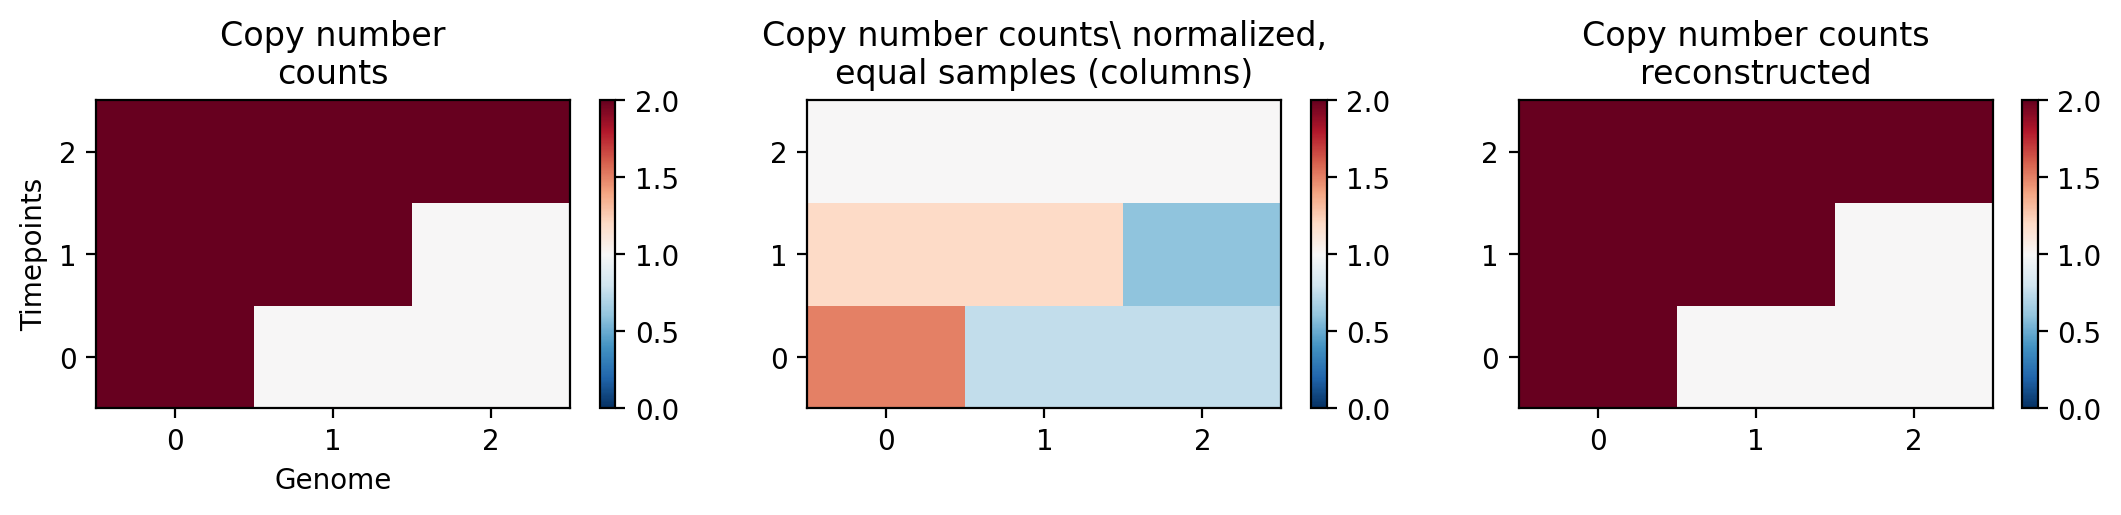

In [89]:
plt.figure(figsize=(13, 2))
plt.subplot(1, 3, 1)
plt.imshow(V.T, aspect='auto', cmap='RdBu_r', vmin=0, vmax=2, origin='lower')
plt.colorbar()
plt.title("Copy number\ncounts")
plt.ylabel("Timepoints")
plt.xlabel("Genome")

plt.subplot(1, 3, 2)
plt.imshow(V_prime.T, aspect='auto', cmap='RdBu_r', vmin=0, vmax=2, origin='lower')
plt.colorbar()
plt.title("Copy number counts\ normalized,\nequal samples (columns)")

plt.subplot(1, 3, 3)
plt.imshow(recontructed_V.T, aspect='auto', cmap='RdBu_r', vmin=0, vmax=2, origin='lower')
plt.colorbar()
plt.title("Copy number counts\nreconstructed")

In [78]:
# Let's take a replication profile and convert it into the equal sample example...
path = 'data/replication_timing/yl_2019/chrom_replication_timing_shared.csv'
chrom_repl_profile = pd.read_csv(path).set_index(['chr', 'start'])
chrom10_replication_profile = chrom_repl_profile.loc[10]

num_indices = 30
n = chrom10_replication_profile.shape[0]

copy_number_matrix = np.ones((n, num_indices))
    
for i in range(chrom10_replication_profile.shape[0]):
    replication_index = chrom10_replication_profile.iloc[i].replication_index-100
    copy_number_matrix[i, replication_index:] = 2


Text(0, 0.5, 'Timepoints')

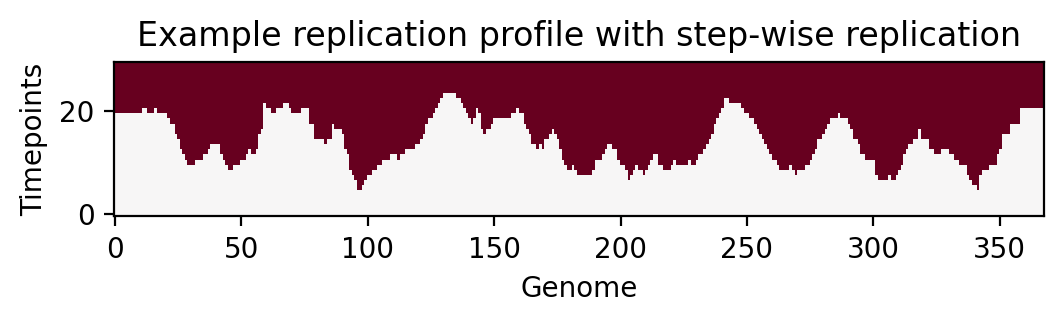

In [90]:
plt.figure(figsize=(6, 1))
plt.imshow(copy_number_matrix.T, origin='lower', aspect='auto', vmin=0, vmax=2, 
          cmap='RdBu_r', interpolation='none')
plt.title("Example replication profile with step-wise replication")
plt.xlabel("Genome")
plt.ylabel("Timepoints")

In [80]:
# Number of origins that have replicated per timepoint
k = (copy_number_matrix > 1).sum(axis=0)
total_copy_number = k*2 + (n-k)
total_copy_number_reshaped = total_copy_number.reshape((1, -1))

normalized_copy_numbers = copy_number_matrix * n / total_copy_number_reshaped

Text(0.5, 1.0, 'Copy number reconstructed')

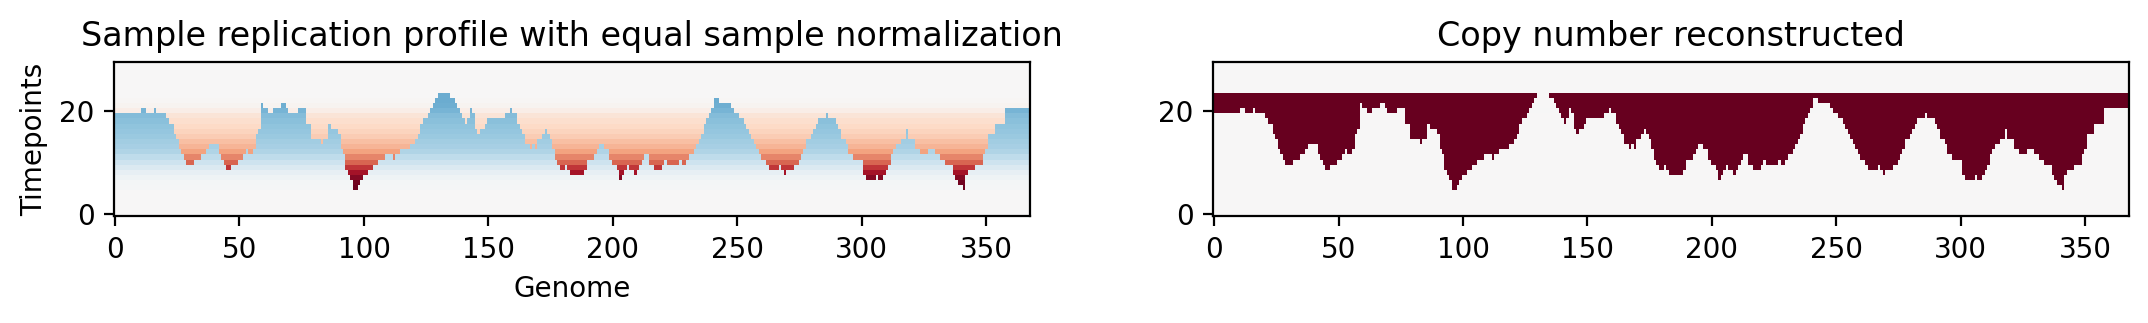

In [91]:
plt.figure(figsize=(13, 1))

plt.subplot(1, 2, 1)
plt.imshow(normalized_copy_numbers.T, origin='lower', aspect='auto', vmin=0, vmax=2, 
          cmap='RdBu_r', interpolation='none')
plt.title("Sample replication profile with equal sample normalization")
plt.xlabel("Genome")
plt.ylabel("Timepoints")

# Estimate the total copy number from the normalized data by 
# counting up regions greater than 1...
total_copy_number_estimation = ((normalized_copy_numbers > 1)+1).sum(axis=0)
copy_number_reconstructed = normalized_copy_numbers * \
    total_copy_number_estimation.reshape((1, -1)) / n

plt.subplot(1, 2, 2)
plt.imshow(copy_number_reconstructed.T, origin='lower', aspect='auto', vmin=0, vmax=2, 
          cmap='RdBu_r', interpolation='none')
plt.title("Copy number reconstructed")

# Reconstsru

In [86]:
# Next step, by hand, what would it look like to have a second and third population that
# is offset from the exact replication timing?
